In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/books_clean_final.csv")

Section 1: Dataset Overview

In [3]:
df.head()

,title,price,genre,rating,genre_group,in_stock,price_band,price_tier,rating_label
0,It's Only the Himalayas,45.17,Travel,2,Lifestyle & Light Reads,True,Upper-Mid,Mid-High,Average
1,Full Moon over Noahs Ark: An Odyssey to Mount ...,49.43,Travel,4,Lifestyle & Light Reads,True,Upper-Mid,Most Expensive,Very Good
2,See America: A Celebration of Our National Par...,48.87,Travel,3,Lifestyle & Light Reads,True,Upper-Mid,Most Expensive,Good
3,Vagabonding: An Uncommon Guide to the Art of L...,36.94,Travel,2,Lifestyle & Light Reads,True,Mid,Mid-High,Average
4,Under the Tuscan Sun,37.33,Travel,3,Lifestyle & Light Reads,True,Mid,Mid-High,Good


In [4]:
df.shape

(780, 9)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 780 entries, 0 to 779
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   title         780 non-null    object 
 1   price         780 non-null    float64
 2   genre         780 non-null    object 
 3   rating        780 non-null    int64  
 4   genre_group   780 non-null    object 
 5   in_stock      780 non-null    bool   
 6   price_band    780 non-null    object 
 7   price_tier    780 non-null    object 
 8   rating_label  780 non-null    object 
dtypes: bool(1), float64(1), int64(1), object(6)
memory usage: 49.6+ KB


In [6]:
total_books = df.shape[0]
total_books

780

In [7]:
df['genre'].nunique()

48

In [8]:
df['genre_group'].nunique()

10

In [9]:
df['genre'].value_counts().head()

genre
Nonfiction        110
Sequential Art     75
Fiction            65
Young Adult        54
Fantasy            47
Name: count, dtype: int64

In [10]:
df['genre_group'].value_counts()

genre_group
Core Fiction                            162
Non-Fiction (General)                   127
History / Psychology / Human Stories    114
Speculative / Intense Fiction            89
Arts / Philosophy / Spiritual            83
Lifestyle & Light Reads                  60
Young Adult / New Adult                  60
Romance                                  35
Children                                 29
Other                                    21
Name: count, dtype: int64

In [11]:
(df['in_stock'].mean()) * 100

100.0

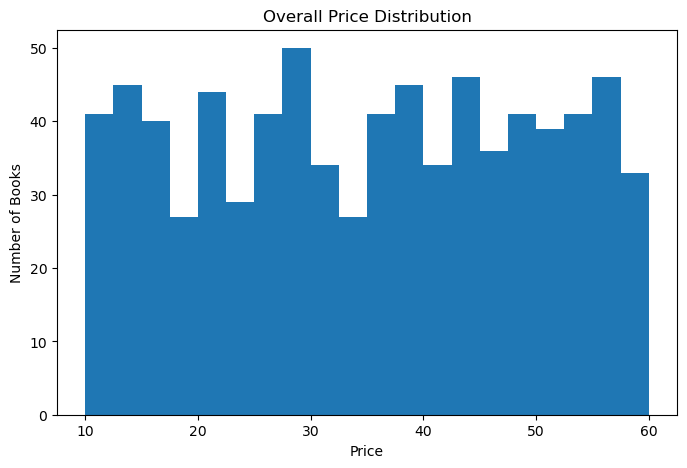

In [12]:
plt.figure(figsize=(8, 5))
plt.hist(df['price'], bins=20)
plt.xlabel('Price')
plt.ylabel('Number of Books')
plt.title('Overall Price Distribution')
plt.show()

In [13]:
avg_price_by_genre = (
    df.groupby('genre_group')['price']
      .mean()
      .sort_values(ascending=False)
)

avg_price_by_genre

genre_group
Speculative / Intense Fiction           36.947865
Young Adult / New Adult                 36.542500
Arts / Philosophy / Spiritual           35.626627
Lifestyle & Light Reads                 35.447167
History / Psychology / Human Stories    35.441579
Other                                   35.218095
Core Fiction                            34.609198
Non-Fiction (General)                   34.066535
Romance                                 33.933714
Children                                32.638276
Name: price, dtype: float64

In [14]:
avg_price_by_genre.reset_index(name='average_price')

,genre_group,average_price
0,Speculative / Intense Fiction,36.947865
1,Young Adult / New Adult,36.542500
2,Arts / Philosophy / Spiritual,35.626627
3,Lifestyle & Light Reads,35.447167
4,History / Psychology / Human Stories,35.441579
5,Other,35.218095
6,Core Fiction,34.609198
7,Non-Fiction (General),34.066535
8,Romance,33.933714
9,Children,32.638276


In [15]:
price_band_counts = df['price_band'].value_counts().sort_index()
price_band_counts

price_band
Low           86
Lower-Mid    232
Mid          226
Upper-Mid    236
Name: count, dtype: int64

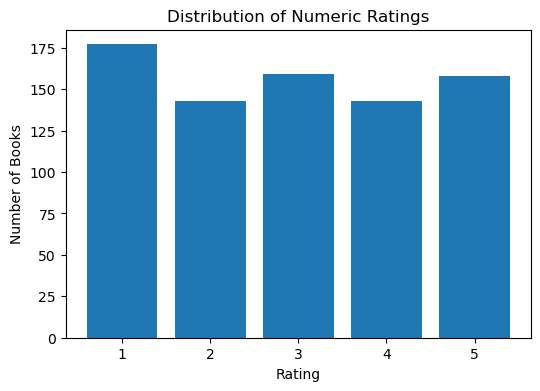

In [16]:
rating_counts = df['rating'].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(rating_counts.index, rating_counts.values)
plt.xlabel('Rating')
plt.ylabel('Number of Books')
plt.title('Distribution of Numeric Ratings')
plt.show()

In [17]:
df['rating_label'].value_counts()

rating_label
Poor         177
Good         159
Excellent    158
Average      143
Very Good    143
Name: count, dtype: int64

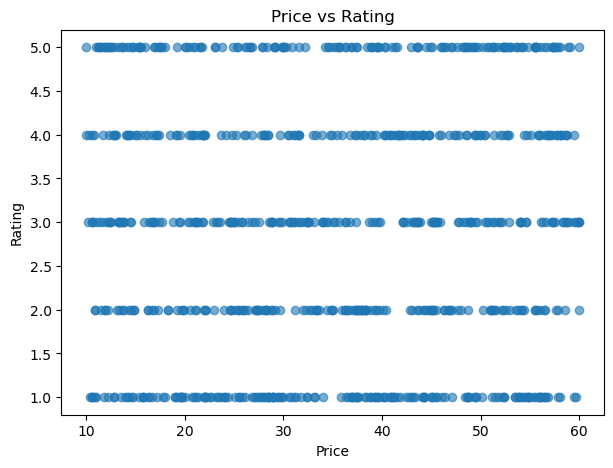

In [18]:
plt.figure(figsize=(7, 5))
plt.scatter(df['price'], df['rating'], alpha=0.6)
plt.xlabel('Price')
plt.ylabel('Rating')
plt.title('Price vs Rating')
plt.show()

In [19]:
avg_rating_by_tier = (
    df.groupby('price_tier')['rating']
      .mean()
      .sort_values(ascending=False)
)

avg_rating_by_tier

price_tier
Most Expensive    3.123711
Cheapest          3.040816
Mid-High          2.852041
Mid-Low           2.788660
Name: rating, dtype: float64

In [20]:
avg_rating_by_tier.reset_index(name='average_rating')

,price_tier,average_rating
0,Most Expensive,3.123711
1,Cheapest,3.040816
2,Mid-High,2.852041
3,Mid-Low,2.788660


In [21]:
avg_rating_by_genre = (
    df.groupby('genre_group')['rating']
      .mean()
      .sort_values(ascending=False)
)

avg_rating_by_genre

genre_group
Young Adult / New Adult                 3.283333
Core Fiction                            3.080247
Arts / Philosophy / Spiritual           3.036145
Lifestyle & Light Reads                 3.016667
Speculative / Intense Fiction           2.921348
History / Psychology / Human Stories    2.877193
Non-Fiction (General)                   2.858268
Romance                                 2.628571
Children                                2.620690
Other                                   2.571429
Name: rating, dtype: float64

In [22]:
avg_rating_by_genre.reset_index(name='average_rating')

,genre_group,average_rating
0,Young Adult / New Adult,3.283333
1,Core Fiction,3.080247
2,Arts / Philosophy / Spiritual,3.036145
3,Lifestyle & Light Reads,3.016667
4,Speculative / Intense Fiction,2.921348
5,History / Psychology / Human Stories,2.877193
6,Non-Fiction (General),2.858268
7,Romance,2.628571
8,Children,2.620690
9,Other,2.571429


In [23]:
avg_price_by_genre = (
    df.groupby('genre_group')['price']
      .mean()
      .sort_values(ascending=False)
)

avg_price_by_genre

genre_group
Speculative / Intense Fiction           36.947865
Young Adult / New Adult                 36.542500
Arts / Philosophy / Spiritual           35.626627
Lifestyle & Light Reads                 35.447167
History / Psychology / Human Stories    35.441579
Other                                   35.218095
Core Fiction                            34.609198
Non-Fiction (General)                   34.066535
Romance                                 33.933714
Children                                32.638276
Name: price, dtype: float64

In [24]:
avg_price_by_genre.reset_index(name='average_price')

,genre_group,average_price
0,Speculative / Intense Fiction,36.947865
1,Young Adult / New Adult,36.542500
2,Arts / Philosophy / Spiritual,35.626627
3,Lifestyle & Light Reads,35.447167
4,History / Psychology / Human Stories,35.441579
5,Other,35.218095
6,Core Fiction,34.609198
7,Non-Fiction (General),34.066535
8,Romance,33.933714
9,Children,32.638276


In [25]:
genre_summary = (
    df.groupby('genre_group')
      .agg(
          average_price=('price', 'mean'),
          average_rating=('rating', 'mean')
      )
)

genre_summary

,average_price,average_rating
genre_group,,
Arts / Philosophy / Spiritual,35.626627,3.036145
Children,32.638276,2.620690
Core Fiction,34.609198,3.080247
History / Psychology / Human Stories,35.441579,2.877193
Lifestyle & Light Reads,35.447167,3.016667
Non-Fiction (General),34.066535,2.858268
Other,35.218095,2.571429
Romance,33.933714,2.628571
Speculative / Intense Fiction,36.947865,2.921348


In [26]:
overall_avg_price = df['price'].mean()
overall_avg_rating = df['rating'].mean()

value_genres = genre_summary[
    (genre_summary['average_rating'] >= overall_avg_rating) &
    (genre_summary['average_price'] <= overall_avg_price)
].sort_values(by='average_rating', ascending=False)

value_genres

,average_price,average_rating
genre_group,,
Core Fiction,34.609198,3.080247


In [27]:
overall_avg_price = df['price'].mean()
overall_avg_rating = df['rating'].mean()

overall_avg_price, overall_avg_rating

(35.14358974358974, 2.9512820512820515)

In [28]:
best_value_books = df[
    (df['price'] <= overall_avg_price) &
    (df['rating'] >= overall_avg_rating)
].sort_values(by=['rating', 'price'], ascending=[False, True])

best_value_books[['title', 'genre_group', 'price', 'rating']].head(10)

,title,genre_group,price,rating
561,An Abundance of Katherines,Young Adult / New Adult,10.00,5
707,The Power Greens Cookbook: 140 Delicious Super...,Lifestyle & Light Reads,11.05,5
247,Dear Mr. Knightley,Core Fiction,11.21,5
556,The Darkest Corners,Young Adult / New Adult,11.33,5
702,"Naturally Lean: 125 Nourishing Gluten-Free, Pl...",Lifestyle & Light Reads,11.38,5
128,"Fruits Basket, Vol. 2 (Fruits Basket #2)",History / Psychology / Human Stories,11.64,5
639,Old School (Diary of a Wimpy Kid #10),Lifestyle & Light Reads,11.83,5
97,Superman Vol. 1: Before Truth (Superman by Gen...,History / Psychology / Human Stories,11.89,5
490,Every Heart a Doorway (Every Heart A Doorway #1),Speculative / Intense Fiction,12.16,5
39,The Girl You Lost,Core Fiction,12.29,5


In [29]:
best_value_books[['title', 'genre_group', 'price', 'rating']].tail(10)

,title,genre_group,price,rating
563,Walk the Edge (Thunder Road #2),Young Adult / New Adult,32.36,3
149,Gone with the Wind,Arts / Philosophy / Spiritual,32.49,3
183,The Wedding Pact (The O'Malleys #2),Romance,32.61,3
712,Hungry Girl Clean & Hungry: Easy All-Natural R...,Lifestyle & Light Reads,33.14,3
729,The Lean Startup: How Today's Entrepreneurs Us...,Non-Fiction (General),33.92,3
431,Kindle Paperwhite User's Guide,Non-Fiction (General),34.00,3
376,"Zero to One: Notes on Startups, or How to Buil...",Non-Fiction (General),34.06,3
711,"The Art of Simple Food: Notes, Lessons, and Re...",Lifestyle & Light Reads,34.32,3
65,The Secret Healer,Core Fiction,34.56,3
478,Throne of Glass (Throne of Glass #1),Speculative / Intense Fiction,35.07,3


In [30]:
poor_value_books = df[
    (df['price'] >= overall_avg_price) &
    (df['rating'] <= overall_avg_rating)
].sort_values(by=['price', 'rating'], ascending=[False, True])

poor_value_books[['title', 'genre_group', 'price', 'rating']].head(10)

,title,genre_group,price,rating
625,Civilization and Its Discontents,History / Psychology / Human Stories,59.95,2
669,Thomas Jefferson and the Tripoli Pirates: The ...,History / Psychology / Human Stories,59.64,1
253,The Improbability of Love,Core Fiction,59.45,1
260,Miller's Valley,Core Fiction,58.54,2
405,"Unstuffed: Decluttering Your Home, Mind, and Soul",Non-Fiction (General),58.09,1
662,The Stand,Speculative / Intense Fiction,57.86,2
415,"Miracles from Heaven: A Little Girl, Her Journ...",Non-Fiction (General),57.83,1
632,Me Talk Pretty One Day,History / Psychology / Human Stories,57.60,2
776,Equal Is Unfair: America's Misguided Fight Aga...,Other,56.86,1
428,Are We Smart Enough to Know How Smart Animals ...,Non-Fiction (General),56.58,1


In [31]:
poor_value_books[['title', 'genre_group', 'price', 'rating']].tail(10)

,title,genre_group,price,rating
727,The E-Myth Revisited: Why Most Small Businesse...,Non-Fiction (General),36.91,1
292,The Bear and the Piano,Children,36.89,1
777,Amid the Chaos,Other,36.58,1
130,"The Wicked + The Divine, Vol. 1: The Faust Act...",History / Psychology / Human Stories,36.52,2
92,Batman: The Long Halloween (Batman),History / Psychology / Human Stories,36.50,2
171,The Nicomachean Ethics,Arts / Philosophy / Spiritual,36.34,1
668,"Political Suicide: Missteps, Peccadilloes, Bad...",History / Psychology / Human Stories,36.28,2
464,The Last Girl (The Dominion Trilogy #1),Core Fiction,36.26,2
375,Chernobyl 01:23:40: The Incredible True Story ...,Non-Fiction (General),35.92,2
768,The Grownup,Other,35.88,1


In [32]:
value_by_band = (
    df.groupby('price_band')
      .agg(
          avg_price=('price', 'mean'),
          avg_rating=('rating', 'mean'),
          book_count=('price', 'count')
      )
)

value_by_band

,avg_price,avg_rating,book_count
price_band,,,
Low,12.597558,3.127907,86
Lower-Mid,22.996250,2.797414,232
Mid,38.049469,2.898230,226
Upper-Mid,52.518220,3.088983,236


In [33]:
value_by_band['rating_per_price'] = (
    value_by_band['avg_rating'] / value_by_band['avg_price']
)

value_by_band.sort_values(by='rating_per_price', ascending=False)

,avg_price,avg_rating,book_count,rating_per_price
price_band,,,,
Low,12.597558,3.127907,86,0.248295
Lower-Mid,22.996250,2.797414,232,0.121647
Mid,38.049469,2.898230,226,0.076170
Upper-Mid,52.518220,3.088983,236,0.058817


In [34]:
df.groupby('genre_group')['in_stock'].value_counts()

genre_group                           in_stock
Arts / Philosophy / Spiritual         True         83
Children                              True         29
Core Fiction                          True        162
History / Psychology / Human Stories  True        114
Lifestyle & Light Reads               True         60
Non-Fiction (General)                 True        127
Other                                 True         21
Romance                               True         35
Speculative / Intense Fiction         True         89
Young Adult / New Adult               True         60
Name: count, dtype: int64

In [35]:
df.groupby('genre_group')['in_stock'].mean() * 100

genre_group
Arts / Philosophy / Spiritual           100.0
Children                                100.0
Core Fiction                            100.0
History / Psychology / Human Stories    100.0
Lifestyle & Light Reads                 100.0
Non-Fiction (General)                   100.0
Other                                   100.0
Romance                                 100.0
Speculative / Intense Fiction           100.0
Young Adult / New Adult                 100.0
Name: in_stock, dtype: float64